In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [2]:
df=pd.read_csv('diabetic_data.csv')

In [3]:
print("Number of Samples:",len(df))

Number of Samples: 101766


In [4]:
df.groupby("readmitted").size()

readmitted
<30    11357
>30    35545
NO     54864
dtype: int64

If we look at the IDs_mapping.csv we can see that 11,13,14,19,20,21 are related to death or hospice. We should remove these samples from the predictive model.

In [5]:
df=df.loc[~df.discharge_disposition_id.isin([11,13,14,19,20,21])]

Here we will try to predict if a patient is likely to be re-admitted within 30 days of discharge

In [6]:
df['OUTPUT_LABEL']=(df.readmitted=="<30").astype('int')

Define a function to calculate the prevalence of population that is readmitted with 30 days.

In [7]:
def calc_prevalence(y_actual):
    return (sum(y_actual)/len(y_actual))

In [8]:
print('Prevalence:%.3f'%calc_prevalence(df['OUTPUT_LABEL'].values))

Prevalence:0.114


Around 11% of the population is rehospitalized. 

IMBALANCED CLASSIFICATION

## FeatureEngineering

In [9]:
df = df.replace('?',np.nan)

### Numerical Features

In [10]:
cols_num = ['time_in_hospital','num_lab_procedures','num_procedures','num_medications','number_outpatient','number_emergency','number_inpatient','number_diagnoses']

In [11]:
df[cols_num].isnull().sum()

time_in_hospital      0
num_lab_procedures    0
num_procedures        0
num_medications       0
number_outpatient     0
number_emergency      0
number_inpatient      0
number_diagnoses      0
dtype: int64

### Categorical Features

In [12]:
cols_cat = ['race','gender','max_glu_serum','A1Cresult','metformin',
           'repaglinide','nateglinide','chlorpropamide','glimepiride',
           'acetohexamide','glipizide','glyburide','tolbutamide','pioglitazone',
           'rosiglitazone','acarbose','miglitol','troglitazone','tolazamide',
           'insulin','glyburide-metformin','glipizide-metformin','glimepiride-pioglitazone',
           'metformin-rosiglitazone','metformin-pioglitazone','change','diabetesMed','payer_code','medical_specialty']

In [13]:
df['race'] = df['race'].fillna('UNK')
df['payer_code']=df['payer_code'].fillna('UNK')
df['medical_specialty']=df['medical_specialty'].fillna('UNK')

In [14]:
print('Number medical specialty:',df.medical_specialty.nunique())
df.groupby('medical_specialty').size().sort_values(ascending = False)

Number medical specialty: 73


medical_specialty
UNK                                 48616
InternalMedicine                    14237
Emergency/Trauma                     7419
Family/GeneralPractice               7252
Cardiology                           5279
                                    ...  
Psychiatry-Addictive                    1
Dermatology                             1
Speech                                  1
SportsMedicine                          1
Surgery-PlasticwithinHeadandNeck        1
Length: 73, dtype: int64

In [15]:
top_10=['UNK','InternalMedicine','Emergency/Trauma',\
       'Family/GeneralPractice','Cardiology','Surgery-General',\
       'Nephrology','Orthopedics',\
       'Orthopedics-Reconstructive','Radiologist']
df['med_spec'] = df['medical_specialty'].copy()
df.loc[~df.med_spec.isin(top_10),'med_spec']='Other'

In [16]:
df.groupby('med_spec').size()

med_spec
Cardiology                     5279
Emergency/Trauma               7419
Family/GeneralPractice         7252
InternalMedicine              14237
Nephrology                     1539
Orthopedics                    1392
Orthopedics-Reconstructive     1230
Other                          8199
Radiologist                    1121
Surgery-General                3059
UNK                           48616
dtype: int64

In [17]:
cols_cat_num = ['admission_type_id','discharge_disposition_id','admission_source_id']
df[cols_cat_num] = df[cols_cat_num].astype('str')

In [18]:
df_cat = pd.get_dummies(df[cols_cat + cols_cat_num+['med_spec']],drop_first= True)

In [19]:
df_cat.head().T

,0,1,2,3,4
race_Asian,0,0,0,0,0
race_Caucasian,1,1,0,1,1
race_Hispanic,0,0,0,0,0
race_Other,0,0,0,0,0
race_UNK,0,0,0,0,0
...,...,...,...,...,...
med_spec_Orthopedics-Reconstructive,0,0,0,0,0
med_spec_Other,1,0,0,0,0
med_spec_Radiologist,0,0,0,0,0
med_spec_Surgery-General,0,0,0,0,0


In [20]:
df= pd.concat([df,df_cat],axis=1)

In [21]:
cols_all_cat = list(df_cat.columns)

### Extra Features

In [22]:
df[['age','weight']].head()

,age,weight
0,[0-10),NaN
1,[10-20),NaN
2,[20-30),NaN
3,[30-40),NaN
4,[40-50),NaN


In [23]:
df.groupby('age').size()

age
[0-10)        160
[10-20)       690
[20-30)      1649
[30-40)      3764
[40-50)      9607
[50-60)     17060
[60-70)     22059
[70-80)     25331
[80-90)     16434
[90-100)     2589
dtype: int64

In [24]:
age_id= {'[0-10)':0,
        '[10-20)':10,
        '[20-30)':20,
        '[30-40)':30,
        '[40-50)':40,
        '[50-60)':50,
        '[60-70)':60,
        '[70-80)':70,
        '[80-90)':80,
        '[90-100)':90}
df['age_group'] = df.age.replace(age_id)

In [25]:
df.weight.notnull().sum()

3125

In [26]:
df['has_weight']=df.weight.notnull().astype('int')

In [27]:
cols_extra=['age_group','has_weight']

In [28]:
df.weight.isnull()

0         True
1         True
2         True
3         True
4         True
          ... 
101761    True
101762    True
101763    True
101764    True
101765    True
Name: weight, Length: 99343, dtype: bool

### Feature Engineering: Summary


In [29]:
print('Total number of features:', len(cols_num + cols_all_cat + cols_extra))
print('Numerical Features:',len(cols_num))
print('Categorical Features:',len(cols_all_cat))
print('Extra features:',len(cols_extra))

Total number of features: 215
Numerical Features: 8
Categorical Features: 205
Extra features: 2


In [30]:
col2use = cols_num+ cols_all_cat+cols_extra
df_data= df[col2use+['OUTPUT_LABEL']]

In [31]:
# shuffle the samples
df_data = df_data.sample(n = len(df_data), random_state = 42)
df_data = df_data.reset_index(drop = True)

# Data Visulization

#### Distribution of Readmission

/Users/maryam/opt/anaconda3/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


Text(0.5, 1.0, 'Distribution of Readmission')

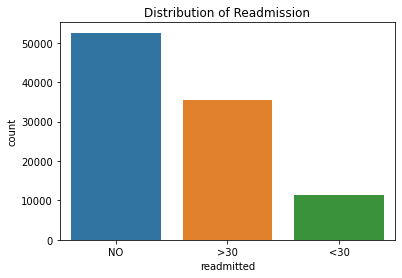

In [32]:
sns.countplot(df['readmitted']).set_title('Distribution of Readmission')

#### Time in Hospital & Readmission

Text(0.5, 1.0, 'Time in Hospital VS. Readmission')

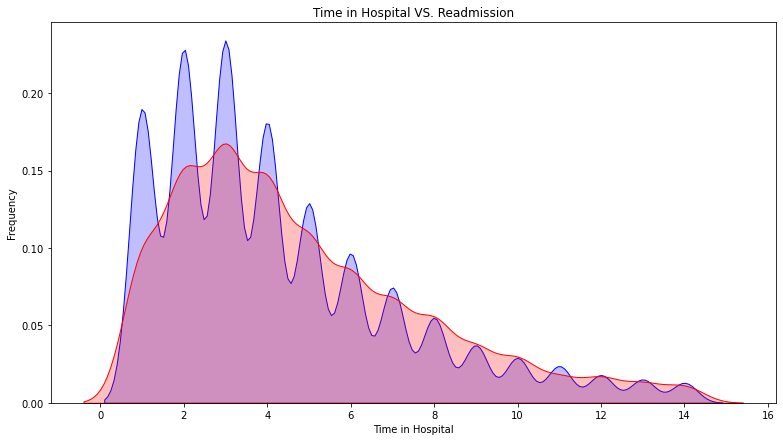

In [33]:
fig = plt.figure(figsize=(13,7),)
ax=sns.kdeplot(df.loc[(df['readmitted'] != '<30'),'time_in_hospital'] , color='b',shade=True,label='Not Readmitted')
ax=sns.kdeplot(df.loc[(df['readmitted'] == '<30'),'time_in_hospital'] , color='r',shade=True, label='Readmitted')
ax.set(xlabel='Time in Hospital', ylabel='Frequency')
plt.title('Time in Hospital VS. Readmission')

#### Age & Readmission

Text(0.5, 1.0, 'Age of Patient VS. Readmission')

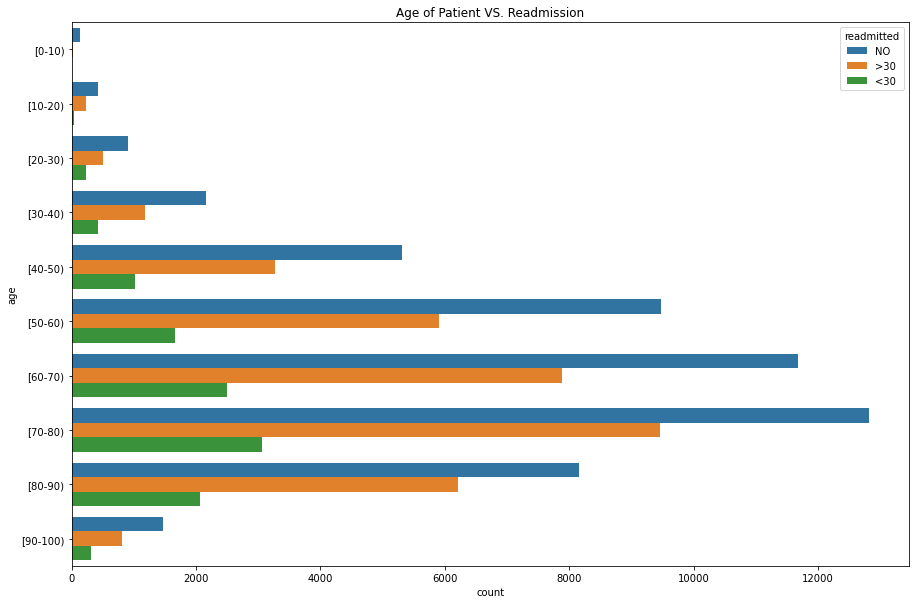

In [34]:
fig = plt.figure(figsize=(15,10))
sns.countplot(y= df['age'], hue = df['readmitted']).set_title('Age of Patient VS. Readmission')

#### Ethinicity of Patient & Readmission

<AxesSubplot:xlabel='count', ylabel='race'>

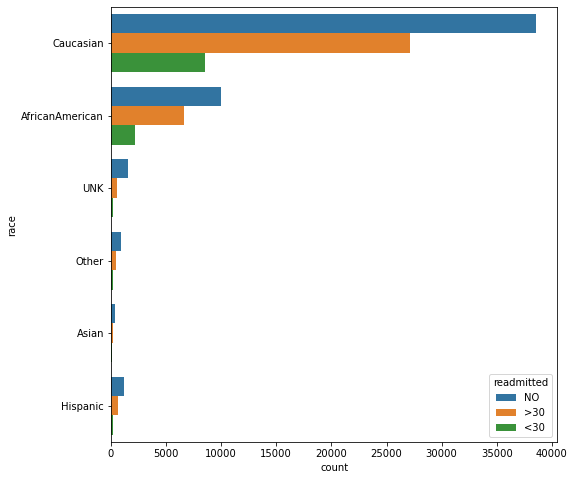

In [35]:
fig = plt.figure(figsize=(8,8))
sns.countplot(y = df['race'], hue = df['readmitted'])

#### Number of Medication & Readmission

Text(0.5, 1.0, 'Number of medication used VS. Readmission')

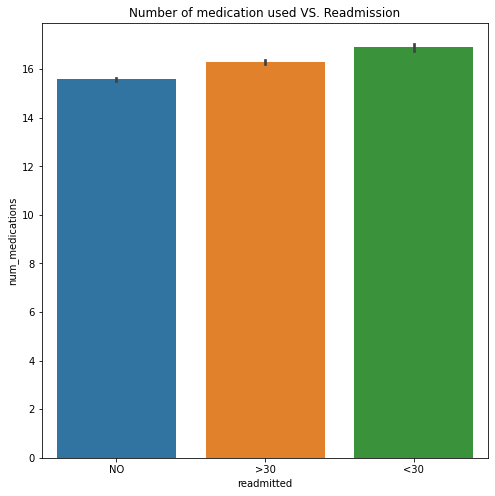

In [36]:
fig = plt.figure(figsize=(8,8))
sns.barplot(x = df['readmitted'], y = df['num_medications']).set_title("Number of medication used VS. Readmission")

#### Gender & Readmission

/Users/maryam/opt/anaconda3/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


Text(0.5, 1.0, 'Gender of Patient VS. Readmission')

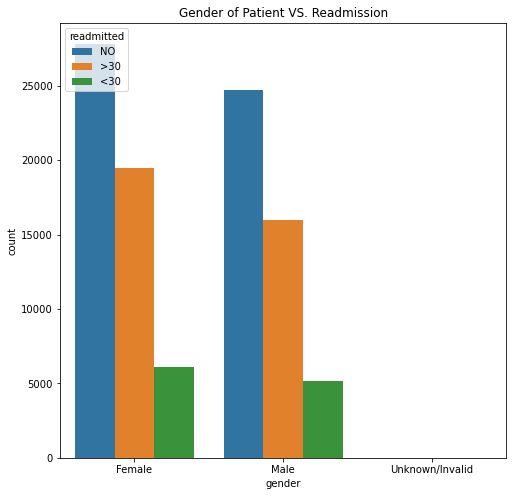

In [37]:
fig = plt.figure(figsize=(8,8))
sns.countplot(df['gender'], hue = df['readmitted']).set_title("Gender of Patient VS. Readmission")

#### Change of Medication & Readmission

/Users/maryam/opt/anaconda3/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


Text(0.5, 1.0, 'Change of Medication VS. Readmission')

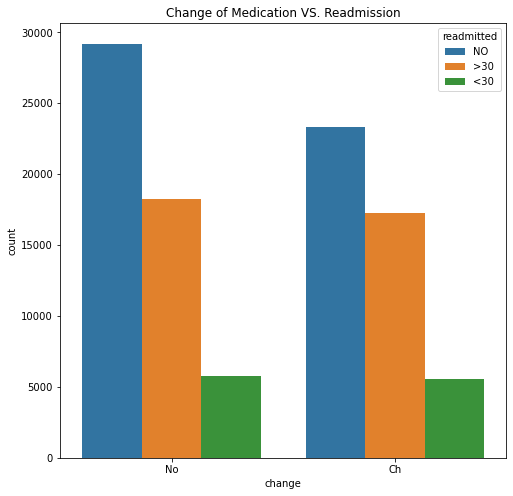

In [38]:
fig = plt.figure(figsize=(8,8))
sns.countplot(df['change'], hue = df['readmitted']).set_title('Change of Medication VS. Readmission')

#### Diabetes Medication prescribed and Readmission

/Users/maryam/opt/anaconda3/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


Text(0.5, 1.0, 'Diabetes Medication prescribed VS Readmission')

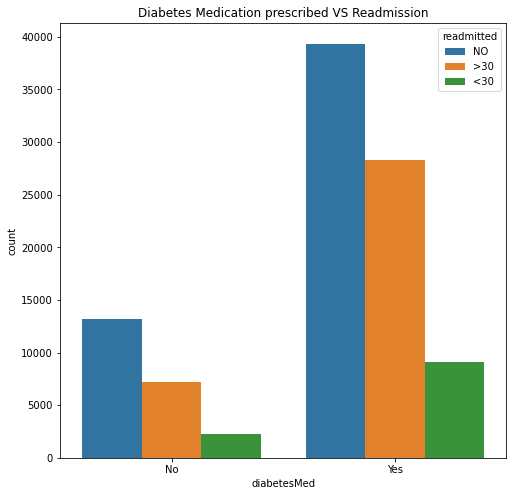

In [39]:
fig = plt.figure(figsize=(8,8))
sns.countplot(df['diabetesMed'], hue = df['readmitted']).set_title('Diabetes Medication prescribed VS Readmission')

#### Glucose serum test Result and Readmission

Text(0.5, 1.0, 'Glucose test serum test result VS. Readmission')

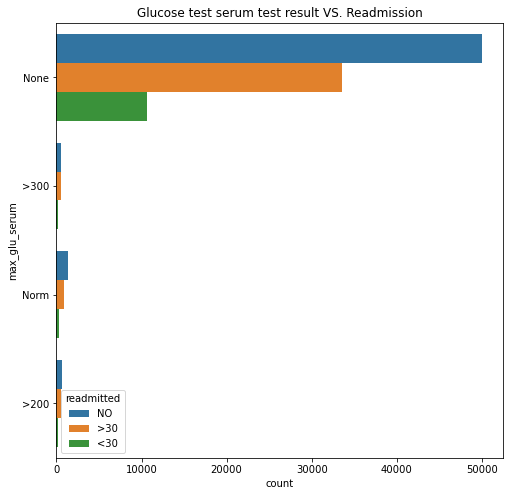

In [40]:
fig = plt.figure(figsize=(8,8))
sns.countplot(y = df['max_glu_serum'], hue = df['readmitted']).set_title('Glucose test serum test result VS. Readmission')

#### A1Cresult & Readmission

Text(0.5, 1.0, 'A1C test result VS. Readmission')

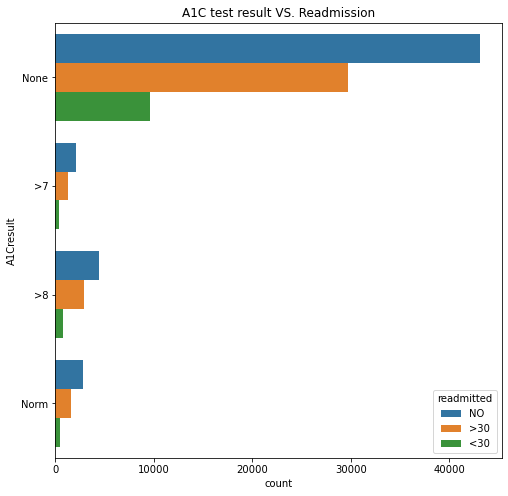

In [41]:
fig = plt.figure(figsize=(8,8))
sns.countplot(y= df['A1Cresult'], hue = df['readmitted']).set_title('A1C test result VS. Readmission')

#### Number Of lab procedures & Readmission

Text(0.5, 1.0, 'Number of lab procedure VS. Readmission')

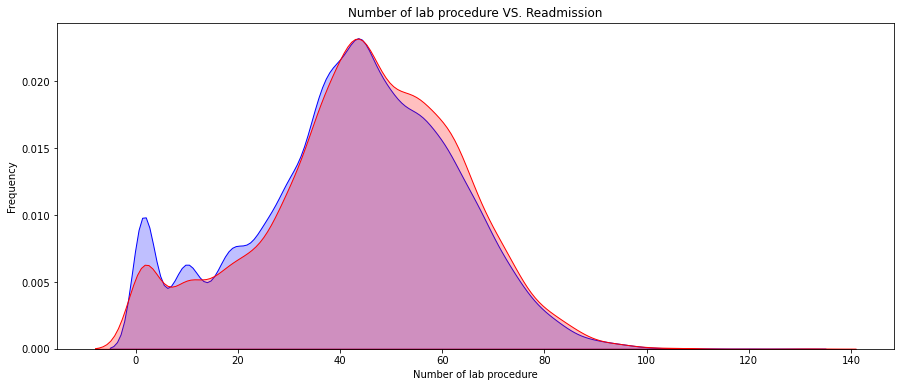

In [42]:
fig = plt.figure(figsize=(15,6),)
ax=sns.kdeplot(df.loc[(df['readmitted'] != '<30'),'num_lab_procedures'] , color='b',shade=True,label='Not readmitted')
ax=sns.kdeplot(df.loc[(df['readmitted'] == '<30'),'num_lab_procedures'] , color='r',shade=True, label='readmitted')
ax.set(xlabel='Number of lab procedure', ylabel='Frequency')
plt.title('Number of lab procedure VS. Readmission')

## Splitting the Data

In [43]:
# Save 50% data in Training set
df_train_all=df_data.sample(frac=0.80,random_state=42)
print('Split size: %.3f'%(len(df_train_all)/len(df_data)))


Split size: 0.800


In [44]:
# use the rest of the data as Testing data
df_test=df_data.drop(df_train_all.index)

In [45]:
print('Test prevalence(n = %d):%.3f'%(len(df_test),calc_prevalence(df_test.OUTPUT_LABEL.values)))
print('Train all prevalence(n = %d):%.3f'%(len(df_train_all), calc_prevalence(df_train_all.OUTPUT_LABEL.values)))

Test prevalence(n = 19869):0.114
Train all prevalence(n = 79474):0.114


In [46]:
print('all samples (n = %d)'%len(df_data))
assert len(df_data) == (len(df_test)+len(df_train_all)),'math didnt work'

all samples (n = 99343)


In [47]:
# split the training data into positive and negative
rows_pos = df_train_all.OUTPUT_LABEL == 1
df_train_pos = df_train_all.loc[rows_pos]
df_train_neg = df_train_all.loc[~rows_pos]

# merge the balanced data
df_train = pd.concat([df_train_pos, df_train_neg.sample(n = len(df_train_pos), random_state = 42)],axis = 0)

# shuffle the order of training samples 
df_train = df_train.sample(n = len(df_train), random_state = 42).reset_index(drop = True)

print('Train balanced prevalence(n = %d):%.3f'%(len(df_train), calc_prevalence(df_train.OUTPUT_LABEL.values)))

Train balanced prevalence(n = 18090):0.500


In [48]:
df_train_all.to_csv('df_train_all.csv',index=False)
df_train.to_csv('df_train.csv',index=False)
df_test.to_csv('df_test.csv',index=False)

In [49]:
X_train = df_train[col2use].values
X_train_all = df_train_all[col2use].values
X_test = df_test[col2use].values

y_train = df_train['OUTPUT_LABEL'].values
y_test = df_test['OUTPUT_LABEL'].values

print('Training All shapes:',X_train_all.shape)
print('Training shapes:',X_train.shape, y_train.shape)
print('Test shapes:',X_test.shape, y_test.shape)

Training All shapes: (79474, 215)
Training shapes: (18090, 215) (18090,)
Test shapes: (19869, 215) (19869,)


### Standard Scaler

In [50]:
from sklearn.preprocessing import StandardScaler

scaler  = StandardScaler()
scaler.fit(X_train_all)

StandardScaler()

In [51]:
import pickle
scalerfile = 'scaler.sav'
pickle.dump(scaler, open(scalerfile, 'wb'))

In [52]:
# load it back
scaler = pickle.load(open(scalerfile, 'rb'))

In [53]:
X_train_tf = scaler.transform(X_train)
X_test_tf = scaler.transform(X_test)

# Modeling

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from IPython.display import Image  
from sklearn.tree import export_graphviz
#import pydotplus
import seaborn as sns
sns.set()
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix

In [57]:
def calc_specificity(y_actual, y_pred, thresh):
    # calculates specificity
    return sum((y_pred < thresh) & (y_actual == 0)) /sum(y_actual ==0)

def print_report(y_actual, y_pred, thresh):
    
    auc = roc_auc_score(y_actual, y_pred)
    accuracy = accuracy_score(y_actual, (y_pred > thresh))
    recall = recall_score(y_actual, (y_pred > thresh))
    precision = precision_score(y_actual, (y_pred > thresh))
    specificity = calc_specificity(y_actual, y_pred, thresh)
    CM = confusion_matrix(y_actual,y_pred, labels=[1,0])
    print('AUC:%.3f'%auc)
    print('accuracy:%.3f'%accuracy)
    print('recall:%.3f'%recall)
    print('precision:%.3f'%precision)
    print('specificity:%.3f'%specificity)
    print('prevalence:%.3f'%calc_prevalence(y_actual))
    print('Confusion Matrix:%.3f'%CM)
    
    print(' ')
    return auc, accuracy, recall, precision, specificity, CM

In [58]:
thresh = 0.5

### KNN

In [59]:
# k-nearest neighbors
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors = 100)
knn.fit(X_train_tf, y_train)

KNeighborsClassifier(n_neighbors=100)

In [60]:
y_test_preds = knn.predict_proba(X_test_tf)[:,1]
#[:,1] means keeping second col


In [62]:
print('KNN')
knn_test_auc, 
knn_test_accuracy, 
knn_test_recall, 
knn_test_precision, knn_test_specificity, knn_test_CM= print_report(y_test,y_test_preds, thresh)

KNN


NameError: name 'knn_test_auc' is not defined

### Logistic Regression 

In [ ]:
# logistic regression
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(random_state = 42)
lr.fit(X_train_tf, y_train)

In [ ]:
y_test_preds = lr.predict_proba(X_test_tf)[:,1]

In [ ]:
print('Logistic Regression')
lr_test_auc, lr_test_accuracy, lr_test_recall, \
    lr_test_precision, lr_test_specificity, lr_test_CM = print_report(y_test,y_test_preds, thresh)

### Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth = 10, random_state = 42)
tree.fit(X_train_tf, y_train)


In [ ]:
y_test_preds = tree.predict_proba(X_test)[:,1]

print('Decision Tree')
tree_test_auc, tree_test_accuracy, tree_test_recall, tree_test_precision, tree_test_specificity, tree_test_CM= print_report(y_test,y_test_preds, thresh)

### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(max_depth = 6, random_state = 42)
rf.fit(X_train, y_train)

In [ ]:
y_test_preds = rf.predict_proba(X_test)[:,1]

print('Random Forest')
rf_test_auc, rf_test_accuracy, rf_test_rmse, rf_test_precision, rf_test_specificity, rf_test_CM= print_report(y_test,y_test_preds, thresh)

# Analyze Baseline Models

In [ ]:
df_results = pd.DataFrame({'classifier':['LR','LR','DT','DT','RF','RF'],
                           'data_set':['train','valid']*3,
                          'auc':[lr_train_auc,lr_valid_auc,tree_train_auc,tree_valid_auc,rf_train_auc,rf_valid_auc],
                          'accuracy':[lr_train_accuracy,lr_valid_accuracy,tree_train_accuracy,tree_valid_accuracy,rf_train_accuracy,rf_valid_accuracy],
                          'rmse':[lr_train_rmse,lr_valid_rmse,tree_train_rmse,tree_valid_rmse,rf_train_rmse,rf_valid_rmse],
                          'precision':[lr_train_precision,lr_valid_precision,tree_train_precision,tree_valid_precision,rf_train_precision,rf_valid_precision]})

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="darkgrid")

In [ ]:
ax = sns.barplot(x="classifier", y="auc", hue="data_set", data=df_results)
ax.set_xlabel('Classifier',fontsize = 15)
ax.set_ylabel('AUC', fontsize = 15)
ax.tick_params(labelsize=15)

# Put the legend out of the figure
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize = 15)
plt.show()

In [ ]:
import numpy as np
from sklearn.model_selection import learning_curve
from sklearn.model_selection import ShuffleSplit

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None,
                        n_jobs=1, train_sizes=np.linspace(.1, 1.0, 5)):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 3-fold cross-validation,
          - integer, to specify the number of folds.
          - An object to be used as a cross-validation generator.
          - An iterable yielding train/test splits.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : integer, optional
        Number of jobs to run in parallel (default 1).
    """
    plt.figure()
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("AUC")
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring = 'roc_auc')
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="b")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="b",
             label="Cross-validation score")

    plt.legend(loc="best")
    return plt

In [ ]:
title = "Learning Curves (Random Forest)"
# Cross validation with 5 iterations to get smoother mean test and train
# score curves, each time with 20% data randomly selected as a validation set.
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)
estimator = RandomForestClassifier(max_depth = 6, random_state = 42)
plot_learning_curve(estimator, title, X_train_tf, y_train, ylim=(0.2, 1.01), cv=cv, n_jobs=4)

plt.show()

## Feature Importance

### Logistic Regression

In [ ]:
feature_importances = pd.DataFrame(lr.coef_[0],
                                   index = col2use,
                                    columns=['importance']).sort_values('importance',
                                                                        ascending=False)

In [ ]:
feature_importances.head()

In [ ]:
num = 50
ylocs = np.arange(num)
# get the feature importance for top num and sort in reverse order
values_to_plot = feature_importances.iloc[:num].values.ravel()[::-1]
feature_labels = list(feature_importances.iloc[:num].index)[::-1]

plt.figure(num=None, figsize=(8, 15), dpi=80, facecolor='w', edgecolor='k');
plt.barh(ylocs, values_to_plot, align = 'center')
plt.ylabel('Features')
plt.xlabel('Importance Score')
plt.title('Positive Feature Importance Score - Logistic Regression')
plt.yticks(ylocs, feature_labels)
plt.show()


### Random Forest

In [ ]:
feature_importances = pd.DataFrame(rf.feature_importances_,
                                   index = col2use,
                                    columns=['importance']).sort_values('importance',
                                                                        ascending=False)

In [ ]:
feature_importances.head()

In [ ]:
num = 50
ylocs = np.arange(num)
# get the feature importance for top num and sort in reverse order
values_to_plot = feature_importances.iloc[:num].values.ravel()[::-1]
feature_labels = list(feature_importances.iloc[:num].index)[::-1]

plt.figure(num=None, figsize=(8, 15), dpi=80, facecolor='w', edgecolor='k');
plt.barh(ylocs, values_to_plot, align = 'center')
plt.ylabel('Features')
plt.xlabel('Importance Score')
plt.title('Feature Importance Score - Random Forest')
plt.yticks(ylocs, feature_labels)
plt.show()


## Model Selection: Hyperparameter tuning

In [ ]:
rf.get_params()

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# number of trees
n_estimators = range(200,1000,200)
# maximum number of features to use at each split
max_features = ['auto','sqrt']
# maximum depth of the tree
max_depth = range(1,10,1)
# minimum number of samples to split a node
min_samples_split = range(2,10,2)
# criterion for evaluating a split
criterion = ['gini','entropy']

# random grid

random_grid = {'n_estimators':n_estimators,
              'max_features':max_features,
              'max_depth':max_depth,
              'min_samples_split':min_samples_split,
              'criterion':criterion}

print(random_grid)

In [ ]:
from sklearn.metrics import make_scorer, roc_auc_score
auc_scoring = make_scorer(roc_auc_score)

In [ ]:
# create the randomized search cross-validation
rf_random = RandomizedSearchCV(estimator = rf, param_distributions = random_grid, 
                               n_iter = 20, cv = 2, scoring=auc_scoring,
                               verbose = 1, random_state = 42)

In [ ]:
# fit the random search model (this will take a few minutes)
t1 = time.time()
rf_random.fit(X_train_tf, y_train)
t2 = time.time()
print(t2-t1)

In [ ]:
rf_random.best_params_

In [ ]:
y_train_preds = rf.predict_proba(X_train_tf)[:,1]
y_valid_preds = rf.predict_proba(X_valid_tf)[:,1]

print('Baseline Random Forest')
rf_train_auc_base = roc_auc_score(y_train, y_train_preds)
rf_valid_auc_base = roc_auc_score(y_valid, y_valid_preds)

print('Training AUC:%.3f'%(rf_train_auc_base))
print('Validation AUC:%.3f'%(rf_valid_auc_base))

print('Optimized Random Forest')
y_train_preds_random = rf_random.best_estimator_.predict_proba(X_train_tf)[:,1]
y_valid_preds_random = rf_random.best_estimator_.predict_proba(X_valid_tf)[:,1]

rf_train_auc = roc_auc_score(y_train, y_train_preds_random)
rf_valid_auc = roc_auc_score(y_valid, y_valid_preds_random)

print('Training AUC:%.3f'%(rf_train_auc))
print('Validation AUC:%.3f'%(rf_valid_auc))


## Hyperparameter tuning results

In [ ]:
df_results = pd.DataFrame({'classifier':['RF','RF'],
                           'data_set':['base','optimized']*1,
                          'auc':[rf_valid_auc_base,rf_valid_auc,
                                 ],
                          })

In [ ]:
df_results

In [ ]:
ax = sns.barplot(x="classifier", y="auc", hue="data_set", data=df_results)
ax.set_xlabel('Classifier',fontsize = 15)
ax.set_ylabel('AUC', fontsize = 15)
ax.tick_params(labelsize=15)
# Put the legend out of the figure
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize = 15)

plt.show()